In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))


class mynnet:
  def __init__(self, input_size,n_hidden1,output_size):

    self.W1 = np.random.randn(input_size,n_hidden1)*0.1
    self.b1 = np.zeros((1,n_hidden1))

    self.W2 = np.random.randn(n_hidden1,output_size)*0.1
    self.b2 = np.zeros((1,output_size))

  def forward(self,X):
    self.z1 = X @ self.W1 + self.b1
    self.z2 = self.z1 @ self.W2 + self.b2
    self.a2 = sigmoid(self.z2)
    return self.a2

  def compute_loss(self,y_pred,y_true,eps=1e-9):
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

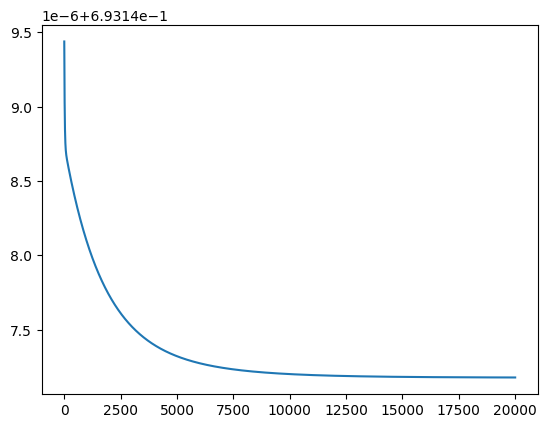

[[0.50001564]
 [0.49996996]
 [0.5000302 ]
 [0.49998452]]


In [15]:
def backprop(net,X,y):
  N = X.shape[0]
  y_pred = net.a2
  dz2 = (y_pred -y)
  dw2 = (net.z1.T @ dz2)/ N
  db2 = np.mean(dz2,axis=0,keepdims=True)

  dz1 = dz2 @ net.W2.T
  dw1 = (X.T @ dz1)/N
  db1 = np.mean(dz1,axis=0,keepdims=True)
  return dw1,db1,dw2,db2


X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([[0],[1],[1],[0]])

model = mynnet(2,4,1)
lr = 0.1
losses = []

for i in range(20000):
  y_pred = model.forward(X_xor)
  loss = model.compute_loss(y_pred,y_xor)
  losses.append(loss)

  dw1,db1,dw2,db2 = backprop(model,X_xor,y_xor)
  model.W1 -= lr * dw1
  model.b1 -= lr * db1
  model.W2 -= lr * dw2
  model.b2 -= lr * db2


plt.plot(losses)
plt.show()

y_pred = model.forward(X_xor)
print(y_pred)

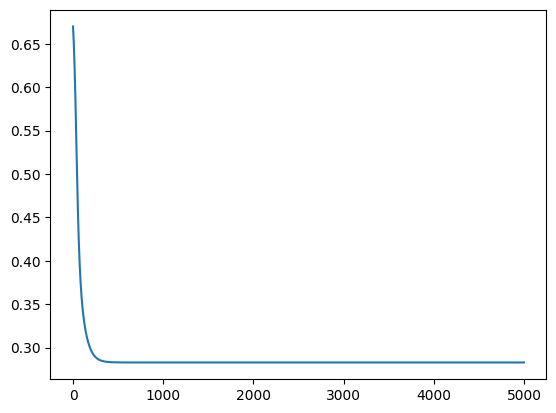

In [25]:
from ast import mod
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=200,noise=0.2)
ym = ym.reshape(-1,1)

def train_model(model, X, y, epochs, lr):
    losses = []
    for epoch in range(epochs):
        y_pred = model.forward(X)
        loss = model.compute_loss(y_pred, y)
        losses.append(loss)
        dw1, db1, dw2, db2 = backprop(model, X, y)
        model.W1 -= lr * dw1
        model.b1 -= lr * db1
        model.W2 -= lr * dw2
        model.b2 -= lr * db2
    return losses

model_moon = mynnet(2,10,1)
losses = train_model(model_moon,Xm,ym,5000,0.1)
plt.plot(losses)
plt.show()



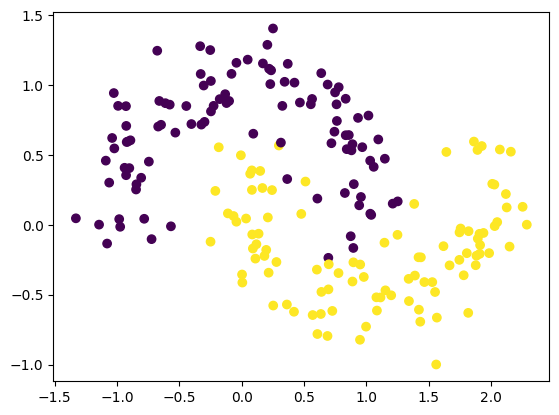

In [26]:
plt.scatter(Xm[:,0],Xm[:,1],c=ym[:,0])
plt.show()